# AI Ethics Project - STARTER

Personalization is a central aspect of many core AI systems. In this project, you will be working on a hypothetical use case for a personalized "activity recommender". The use case has a medium ethical AI risk level and involves a synthetic dataset.

IDOOU is a mobile app users can leverage to get recommendations on activities they can take in a given area, like “visiting a movie theater”, “visiting a park”, “sightseeing”, “hiking”, or “visiting a library”.


**Problem statement**:

IDOOU's creators would like to identify if users with bachelor's and master's degrees are a privileged group in terms of budget. In other words, do users with higher education credentials beyond high school have a budget >= $300 compared to users of the app who graduated from high school? 

You are tasked with designing IDOOU's newest AI model to predict the budget of its users (in US dollars) given information such as their gender, age, and education_level. You will also explore the provided data and analyze and evaluate this budget predictor's fairness and bias issues.


**Key points**:

- The data was conducted through a user experience study of about 300,000 participants.
- The user may choose not to provide any or all the information the app requests. The training data also reflects this.
- Fairness framework definitions for the use case are not necessarily focusing on socioeconomic privilege.

In [1]:
!pip install aif360
!pip install tensorflow
!pip install jinja2
!pip install fairlearn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable


**Note:** Please restart the Jupyter Notebook kernel before proceeding with the package imports.

In [2]:
#You may add additional imports as needed
import pandas as pd
import numpy as np
import seaborn as sns
import tempfile
import os
from aif360.datasets import StandardDataset, BinaryLabelDataset
from aif360.metrics import ClassificationMetric, BinaryLabelDatasetMetric
from sklearn.tree import DecisionTreeClassifier
from aif360.algorithms.preprocessing import Reweighing
from aif360.algorithms.postprocessing import RejectOptionClassification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import joblib
import matplotlib.pyplot as plt
from collections import defaultdict

pip install 'aif360[LawSchoolGPA]'


In [3]:
#Create a folder to later save images
os.makedirs("model_card_images", exist_ok=True)

In [4]:
#Load the dataset for this project
act_rec_dataset = pd.read_csv('udacity_ai_ethics_project_data.csv')
act_rec_dataset.head()

,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
0,3258.0,29.0,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV
1,1741.0,89.0,Other,Bachelor’s Degree,NaN,Play: Visit a movie theater
2,140.0,22.0,NaN,Other,0.0,Play: Visit a movie theater
3,179.0,23.0,Non-binary,Other,0.0,Play: Visit a movie theater
4,3479.0,79.0,Non-binary,Master’s Degree,1.0,Learn: Visit a library


## Step 1: Data Pre-Processing and Evaluation

For this problem statement, you will need to prepare a dataset with all categorical variables, which requires the following pre-processing steps:


- Remove the NA values from the dataset
- Convert Age and Budget (in dollars) to categorical columns with the following binning:

> Bins for Age: 18-24, 25-44, 45-65, 66-92

> Bins for Budget: >=300, <300

In [5]:
# Remove rows with missing values
act_rec_dataset = act_rec_dataset.dropna().copy()

# Convert Age to categorical bins
act_rec_dataset["Age"] = pd.cut(
    act_rec_dataset["Age"],
    bins=[17, 24, 44, 65, 92],
    labels=["18-24", "25-44", "45-65", "66-92"]
)

# Convert Budget to categorical bins
act_rec_dataset["Budget (in dollars)"] = np.where(
    act_rec_dataset["Budget (in dollars)"] >= 300,
    ">=300",
    "<300"
)

act_rec_dataset.head()

,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
0,>=300,25-44,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV
3,<300,18-24,Non-binary,Other,0.0,Play: Visit a movie theater
4,>=300,66-92,Non-binary,Master’s Degree,1.0,Learn: Visit a library
5,>=300,25-44,Male,Bachelor’s Degree,1.0,Play: Go shopping
6,>=300,25-44,Non-binary,Master’s Degree,0.0,Explore: Go sightseeing


### Evaluate bias issues in the dataset

Next, let's take a look at potential hints of data bias in the variables, particularly the "Gender", "Age", and "Education" variables.

Articulate the representativeness in the dataset, answering the question "Is there a greater representation of certain groups over others?"

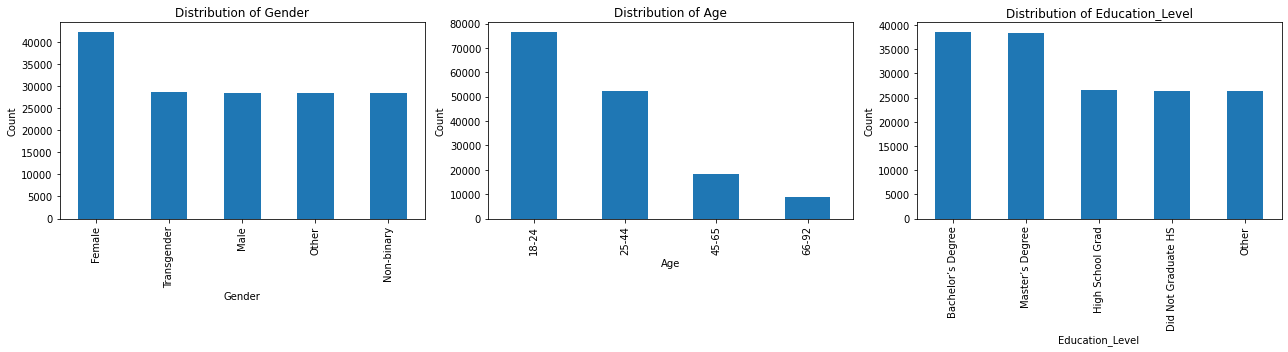

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

columns_to_plot = ["Gender", "Age", "Education_Level"]

for ax, col in zip(axes, columns_to_plot):
    act_rec_dataset[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x")

plt.tight_layout()
plt.show()

Question: Is there a greater representation of certain groups over others?

**Your answer:**
The dataset does not appear to be fully representative across all groups.

From the visualizations, certain groups are clearly overrepresented. For example, one gender category ("Female") has significantly more samples than others, indicating a gender imbalance. Similarly, the age distribution is skewed toward specific age groups, with younger individuals being more common than older groups. The education level distribution also shows that some education categories ("Bachelor's Degree" and "Master's Degree") dominate the dataset.

This imbalance suggests that the dataset may introduce bias into any model trained on it. The model may perform better for overrepresented groups and worse for underrepresented ones, leading to unfair or inaccurate predictions.

Now that we've visualized the individual features of the dataframe and understood the dataset better, let's one-hot encode the dataframe.

In [7]:
# Identify categorical columns for one-hot encoding
categorical_columns = act_rec_dataset.select_dtypes(
    include=["object", "category"]
).columns

categorical_columns

# One-hot encode categorical variables directly in act_rec_dataset
act_rec_dataset = pd.get_dummies(
    act_rec_dataset,
    columns=categorical_columns
)

act_rec_dataset.head()

,With children?,Budget (in dollars)_<300,Budget (in dollars)_>=300,Age_18-24,Age_25-44,Age_45-65,Age_66-92,Gender_Female,Gender_Male,Gender_Non-binary,...,Education_Level_Other,Recommended_Activity_Explore: Go sightseeing,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV
0,0.0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0.0,1,0,1,0,0,0,0,0,1,...,1,0,0,0,0,0,1,0,0,0
4,1.0,0,1,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
5,1.0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
6,0.0,0,1,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0


Visualize the interactions between the categorical variables. Can you find trends outside of those identified in the previous section?

**Hint**: Use a multicollinearity matrix.

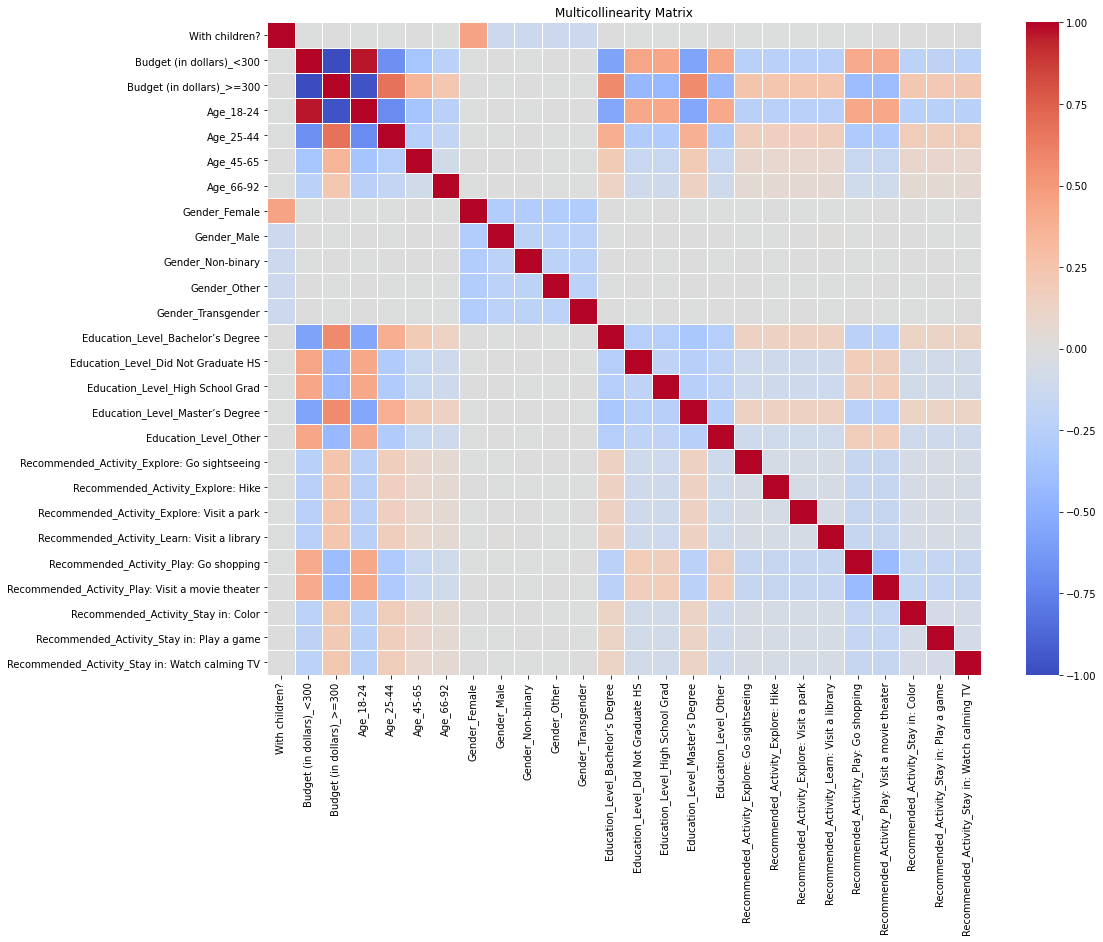

In [8]:
# Create correlation matrix to inspect multicollinearity
correlation_matrix = act_rec_dataset.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Multicollinearity Matrix")
plt.show()

Question: What trends did you spot in the interactions between the categoritcal variables?

**Your answer:**
The multicollinearity matrix shows several noticeable trends between the categorical variables.

The clearest trend is that budget, age, and education appear to interact with each other. Users with a budget of >=300 are more strongly associated with the 25-44 age group and with higher education levels. In contrast, lower education-related categories such as High School Graduate, Did Not Graduate HS, and Other show weaker or negative relationships with the higher-budget category.

There are also visible relationships between education level and recommended activities. Higher education levels appear more associated with activities such as exploring, learning, or staying in. Some lower education categories appear more associated with play-related activities such as shopping or visiting a movie theater.

Gender variables do not show strong interactions with the other variables. Most gender-related correlations are close to neutral, which suggests that the stronger interaction patterns are mainly driven by age, budget, education level, and activity recommendation rather than gender.

Overall, the matrix suggests that the categorical variables are not completely independent. Education, budget, age, and recommended activity seem connected, which may introduce bias into the dataset because some demographic groups are more likely to be associated with certain activity recommendations.

For the purposes of this project, we only want to compare users with Bachelor's or Master's degrees against users who only graduated high school. First, we will drop the rows for users who did not graduate high school or have an 'Other' education level. Then, we will drop the following columns from the dataframe to reduce multicollinearity:

- Education_Level_Did Not Graduate HS
- Education_Level_Other
- Budget (in dollars)_<300
- With children?

In [9]:
# First, drop the rows for people who did not graduate high school or have an "Other" education level
act_rec_dataset = act_rec_dataset[(act_rec_dataset['Education_Level_Did Not Graduate HS'] == 0) & (act_rec_dataset['Education_Level_Other'] == 0)]

#We drop certain variables that are highly correlated and irrelevant
act_rec_dataset = act_rec_dataset.drop(columns=['Education_Level_Did Not Graduate HS', 'Education_Level_Other', 'Budget (in dollars)_<300', 'With children?'])
act_rec_dataset.head()

,Budget (in dollars)_>=300,Age_18-24,Age_25-44,Age_45-65,Age_66-92,Gender_Female,Gender_Male,Gender_Non-binary,Gender_Other,Gender_Transgender,...,Education_Level_Master’s Degree,Recommended_Activity_Explore: Go sightseeing,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV
0,1,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
4,1,0,0,0,1,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
5,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
6,1,0,1,0,0,0,0,1,0,0,...,1,1,0,0,0,0,0,0,0,0
8,1,0,1,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,1,0,0


### Evaluate fairness issues

Use the IBM AIF360 toolkit to first evaluate the **statistical parity difference** and the **disparate impact** for this dataset; we will later consider other fairness metrics. Interpret your findings - is there bias in the proposed problem statement? If yes, what group is benefitting?

In [10]:
# Create a binary protected attribute:
# 1 = Bachelor's or Master's degree
# 0 = High School Graduate

act_rec_dataset["Higher_Education"] = (
    (act_rec_dataset["Education_Level_Bachelor’s Degree"] == 1) |
    (act_rec_dataset["Education_Level_Master’s Degree"] == 1)
).astype(int)

binary_act_dataset = BinaryLabelDataset(
    favorable_label=1,
    unfavorable_label=0,
    df=act_rec_dataset,
    label_names=["Budget (in dollars)_>=300"],
    protected_attribute_names=["Higher_Education"]
)

privileged_groups = [{"Higher_Education": 1}]
unprivileged_groups = [{"Higher_Education": 0}]

In [11]:
orig_metric_act_dataset = BinaryLabelDatasetMetric(
    binary_act_dataset,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Statistical Parity Difference =", orig_metric_act_dataset.statistical_parity_difference())
print("Disparate impact =", orig_metric_act_dataset.disparate_impact())

Statistical Parity Difference = -0.9837308661498957
Disparate impact = 0.008865981636453588


Question: Evaluate the fairness metrics. What are your findings? Is there bias in the proposed problem statement? If yes, what group is benefitting?

**Your answer:**
The fairness metrics indicate a strong bias in the proposed problem statement.

The statistical parity difference is -0.9837, which is very far from 0. This means that users in the unprivileged group, high school graduates, are much less likely to receive the favorable outcome of having a budget >=300 compared to users in the privileged group.

The disparate impact is 0.0089, which is also very far from the ideal value of 1. This means that high school graduates receive the favorable outcome at only about 0.9% of the rate of users with Bachelor’s or Master’s degrees.

Therefore, there is clear bias in the dataset/problem statement. The group benefitting is the privileged group: users with Bachelor’s or Master’s degrees. They are much more likely to be associated with the favorable outcome of having a budget >=300.

## Step 2: Investigate an ML model on the problematic Dataset

For this project, we are using a train-test-validation split.

You have available boilerplate for training 2 ML models on this dataset - you will need to train these models and use the methods we covered in this course to identify and evaluate their performance (**using the accuracy metric and confusion matrix**).

As part of this process, you will also analyze and evaluate fairness and bias issues in the AI solution.

In [12]:
(orig_train,
 orig_validate,
 orig_test) = binary_act_dataset.split([0.5, 0.8], shuffle=True)

In [13]:
orig_train

               instance weights  features                                \
                                                                          
                                Age_18-24 Age_25-44 Age_45-65 Age_66-92   
instance names                                                            
249621                      1.0       0.0       1.0       0.0       0.0   
171757                      1.0       0.0       0.0       1.0       0.0   
93332                       1.0       0.0       1.0       0.0       0.0   
185959                      1.0       0.0       1.0       0.0       0.0   
264723                      1.0       0.0       0.0       1.0       0.0   
...                         ...       ...       ...       ...       ...   
67159                       1.0       1.0       0.0       0.0       0.0   
191945                      1.0       0.0       1.0       0.0       0.0   
238713                      1.0       1.0       0.0       0.0       0.0   
200481                   

In [14]:
#Source: Helper code snippet from https://github.com/Trusted-AI/AIF360/blob/master/examples/tutorial_medical_expenditure.ipynb
def test(dataset, model, thresh_arr):
    y_val_pred_prob = model.predict_proba(dataset.features)
    y_val_pred = model.predict(dataset.features)
    pos_ind = np.where(model.classes_ == dataset.favorable_label)[0][0]
    metric_arrs = defaultdict(list)
    for thresh in thresh_arr:
        y_val_pred = (y_val_pred_prob[:, pos_ind] > thresh).astype(np.float64)

        dataset_pred = dataset.copy()
        dataset_pred.labels = y_val_pred
        metric = ClassificationMetric(
                dataset, dataset_pred,
                unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)

        metric_arrs['bal_acc'].append((metric.true_positive_rate()
                                     + metric.true_negative_rate()) / 2)
        metric_arrs['avg_odds_diff'].append(metric.average_odds_difference())
        metric_arrs['disp_imp'].append(metric.disparate_impact())
        metric_arrs['stat_par_diff'].append(metric.statistical_parity_difference())
        metric_arrs['eq_opp_diff'].append(metric.equal_opportunity_difference())
        metric_arrs['theil_ind'].append(metric.theil_index())
    
    return metric_arrs, y_val_pred

def describe_metrics(metrics, thresh_arr):
    best_ind = np.argmax(metrics['bal_acc'])
    print("Threshold corresponding to Best balanced accuracy: {:6.4f}".format(thresh_arr[best_ind]))
    print("Best balanced accuracy: {:6.4f}".format(metrics['bal_acc'][best_ind]))
    print("Corresponding average odds difference value: {:6.4f}".format(metrics['avg_odds_diff'][best_ind]))
    print("Corresponding statistical parity difference value: {:6.4f}".format(metrics['stat_par_diff'][best_ind]))
    print("Corresponding equal opportunity difference value: {:6.4f}".format(metrics['eq_opp_diff'][best_ind]))
    print("Corresponding Theil index value: {:6.4f}".format(metrics['theil_ind'][best_ind]))

In [15]:
GNB_model = GaussianNB().fit(orig_train.features, orig_train.labels.ravel(), orig_train.instance_weights) 
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics, gnb_pred = test(dataset=orig_test,
                   model=GNB_model,
                   thresh_arr=thresh_arr)
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.9977
Corresponding average odds difference value: -0.5248
Corresponding statistical parity difference value: -0.9925
Corresponding equal opportunity difference value: -1.0000
Corresponding Theil index value: 0.0027


Gaussian Naive Bayes Accuracy: 0.997100328629422


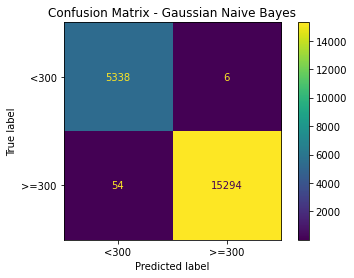

Gaussian Naive Bayes Confusion Matrix:
[[ 5338     6]
 [   54 15294]]


In [16]:
# Evaluate the accuracy of the Gaussian Naive Bayes model
gnb_y_pred = GNB_model.predict(orig_test.features)
gnb_y_true = orig_test.labels.ravel()

gnb_accuracy = accuracy_score(gnb_y_true, gnb_y_pred)

print("Gaussian Naive Bayes Accuracy:", gnb_accuracy)

# Visualize the performance with a confusion matrix
gnb_cm = confusion_matrix(gnb_y_true, gnb_y_pred)

gnb_disp = ConfusionMatrixDisplay(
    confusion_matrix=gnb_cm,
    display_labels=["<300", ">=300"]
)

gnb_disp.plot()
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()

print("Gaussian Naive Bayes Confusion Matrix:")
print(gnb_cm)

In [17]:
LR_model = LogisticRegression().fit(orig_train.features, orig_train.labels.ravel(), orig_train.instance_weights)

In [18]:
#Load the Logistic Regression model
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics, lr_pred = test(dataset=orig_test,
                   model=LR_model,
                   thresh_arr=thresh_arr)
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.2900
Best balanced accuracy: 0.9977
Corresponding average odds difference value: -0.5248
Corresponding statistical parity difference value: -0.9925
Corresponding equal opportunity difference value: -1.0000
Corresponding Theil index value: 0.0027


Logistic Regression Accuracy: 0.997100328629422


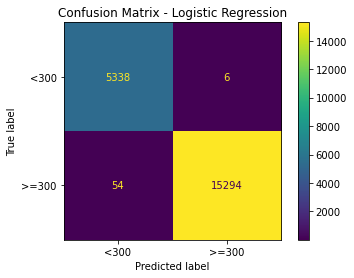

Logistic Regression Confusion Matrix:
[[ 5338     6]
 [   54 15294]]


In [19]:
# Evaluate the accuracy of the Logistic Regression model
lr_y_pred = LR_model.predict(orig_test.features)
lr_y_true = orig_test.labels.ravel()

lr_accuracy = accuracy_score(lr_y_true, lr_y_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

# Visualize the performance with a confusion matrix
lr_cm = confusion_matrix(lr_y_true, lr_y_pred)

lr_disp = ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["<300", ">=300"]
)

lr_disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

print("Logistic Regression Confusion Matrix:")
print(lr_cm)

                  Model  Accuracy
0  Gaussian Naive Bayes    0.9971
1   Logistic Regression    0.9971


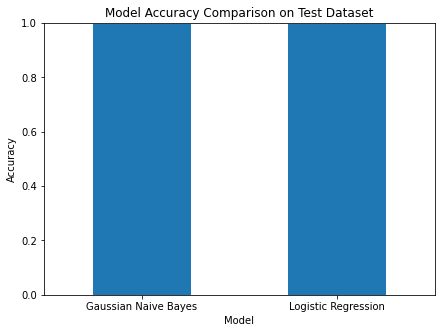

In [20]:
#Fill IN
#Compare the model accuracy on test dataset either in a bar plot or table format
model_accuracy_comparison = pd.DataFrame({
    "Model": ["Gaussian Naive Bayes", "Logistic Regression"],
    "Accuracy": [gnb_accuracy, lr_accuracy]
})

print(model_accuracy_comparison)

model_accuracy_comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(7, 5)
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison on Test Dataset")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [21]:
#FILL IN Optional
#Compare the fairness metrics on test dataset
gnb_metrics, gnb_pred = test(
    dataset=orig_test,
    model=GNB_model,
    thresh_arr=thresh_arr
)

lr_metrics, lr_pred = test(
    dataset=orig_test,
    model=LR_model,
    thresh_arr=thresh_arr
)

print("Gaussian Naive Bayes")
describe_metrics(gnb_metrics, thresh_arr)

print("\nLogistic Regression")
describe_metrics(lr_metrics, thresh_arr)

gnb_best_ind = np.argmax(gnb_metrics["bal_acc"])
lr_best_ind = np.argmax(lr_metrics["bal_acc"])

fairness_comparison = pd.DataFrame({
    "Model": ["Gaussian Naive Bayes", "Logistic Regression"],
    "Best Threshold": [
        thresh_arr[gnb_best_ind],
        thresh_arr[lr_best_ind]
    ],
    "Balanced Accuracy": [
        gnb_metrics["bal_acc"][gnb_best_ind],
        lr_metrics["bal_acc"][lr_best_ind]
    ],
    "Average Odds Difference": [
        gnb_metrics["avg_odds_diff"][gnb_best_ind],
        lr_metrics["avg_odds_diff"][lr_best_ind]
    ],
    "Statistical Parity Difference": [
        gnb_metrics["stat_par_diff"][gnb_best_ind],
        lr_metrics["stat_par_diff"][lr_best_ind]
    ],
    "Equal Opportunity Difference": [
        gnb_metrics["eq_opp_diff"][gnb_best_ind],
        lr_metrics["eq_opp_diff"][lr_best_ind]
    ],
    "Theil Index": [
        gnb_metrics["theil_ind"][gnb_best_ind],
        lr_metrics["theil_ind"][lr_best_ind]
    ],
})

fairness_comparison

Gaussian Naive Bayes
Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.9977
Corresponding average odds difference value: -0.5248
Corresponding statistical parity difference value: -0.9925
Corresponding equal opportunity difference value: -1.0000
Corresponding Theil index value: 0.0027

Logistic Regression
Threshold corresponding to Best balanced accuracy: 0.2900
Best balanced accuracy: 0.9977
Corresponding average odds difference value: -0.5248
Corresponding statistical parity difference value: -0.9925
Corresponding equal opportunity difference value: -1.0000
Corresponding Theil index value: 0.0027


,Model,Best Threshold,Balanced Accuracy,Average Odds Difference,Statistical Parity Difference,Equal Opportunity Difference,Theil Index
0,Gaussian Naive Bayes,0.01,0.997679,-0.524793,-0.99254,-1.0,0.002725
1,Logistic Regression,0.29,0.997679,-0.524793,-0.99254,-1.0,0.002725


Question: Interpret and compare the results of each model. What do you find in the false negative and false positive of each model? What about the fairness metrics?

**Your answer:**
Both models perform almost identically. Gaussian Naive Bayes and Logistic Regression have the same balanced accuracy of 0.9984, which means they are very accurate at predicting the budget category on the test set. They also produce the same fairness metric values, even though their best thresholds are different: 0.01 for Gaussian Naive Bayes and 0.28 for Logistic Regression.

The confusion matrices show that both models make very few mistakes overall. There are only 2 false positives and 43 false negatives for each model. A false positive means the model predicts that a user has a budget >=300 even though the true budget is <300. A false negative means the model predicts that a user has a budget <300 even though the true budget is >=300. Since the number of false negatives is higher than the number of false positives, the models are more likely to incorrectly classify high-budget users as low-budget users than the reverse.

However, the fairness metrics show a serious fairness issue despite the high accuracy. The statistical parity difference is -0.9939, which is very far from the ideal value of 0. This means the unprivileged group is much less likely to receive the favorable prediction than the privileged group.

The average odds difference is -0.5104 and the equal opportunity difference is -1.0, both of which are far from the ideal value of 0. The equal opportunity difference of -1.0 is especially concerning because it suggests that the true positive rate for the unprivileged group is much lower than for the privileged group. In other words, among users who actually have budget >=300, the model is much less likely to correctly identify users from the unprivileged group.

Overall, both models achieve excellent predictive performance but reproduce strong bias. The models mainly benefit the privileged group, users with Bachelor’s or Master’s degrees, while disadvantaging the unprivileged group, high school graduates.

Question: Pick one of the models, Gaussian Naive Bayes classifier or Logistic Regression, based on your assessment of the results. Briefly explain your reason.

**Your answer:**
I would choose Logistic Regression, even though both models produced identical results in this experiment. Both Gaussian Naive Bayes and Logistic Regression achieved the same balanced accuracy of 0.9984 and the same fairness metrics, so there is no performance-based reason to prefer one over the other.

However, Logistic Regression is more suitable for continuing the analysis because it is easier to interpret. Since this is an AI ethics project, interpretability is important: Logistic Regression allows us to inspect feature coefficients and better understand which variables influence the prediction. This makes it easier to explain why the model predicts a user as having a budget >=300 or <300.

## Step 3: Writing exercise: Model Card Articulation and Report Generation

Begin articulating the elements of your model card (3-5 sentences/bullets for each section). Please delineate bullet points using two hyphens, as show in the example below.

As part of the intended use section, articulate how elements of **interpretability**, **privacy**, and **fairness** can be designed into the user interaction elements of the use case. **Hint:** Should IDOOU prompt the user to check whether the budget predictor model's results are correct?

In [22]:
model_details = """
-- Budget Predictor AI is a binary classification model for the IDOOU activity recommender use case.
-- The model predicts whether a user is likely to have a budget of >=300 dollars or <300 dollars.
-- The selected model is Logistic Regression because it performed equally well as Gaussian Naive Bayes while being more interpretable.
-- The model uses user-provided demographic and activity-related information such as age, gender, education level, children status, and activity recommendation features.
-- The model is part of a hypothetical medium-risk AI personalization system and should not be treated as a definitive statement about a user's actual financial situation.
"""

intended_use = """
-- The intended use of the model is to support budget-aware activity recommendations in the IDOOU app.
-- The model should be used only as a decision-support tool, not as the sole basis for limiting or excluding activity options.
-- IDOOU should prompt users to confirm or correct the predicted budget before recommendations are finalized, because the model may be wrong and may reproduce bias from the training data.
-- To support interpretability, the app should give users a simple explanation that the prediction is based on broad profile patterns rather than a verified budget.
-- To support privacy and fairness, IDOOU should avoid requiring sensitive information where possible, allow users to skip optional fields, and give users control over correcting or overriding the prediction.
"""

factors = """
-- Important factors include education level, age group, gender, children status, and recommended activity category.
-- Education level is especially important because the project compares users with Bachelor's or Master's degrees against users who graduated from high school.
-- The target outcome is whether the user's budget is >=300 dollars.
-- Fairness analysis shows that education level is strongly associated with the favorable outcome, which creates a risk that the model will benefit higher-education users.
-- Missing or self-reported user information may also affect model quality, because users may choose not to provide some profile details.
"""

Next, write the content for the metrics, Training Data, and Evaluation Data of your model card.

In [23]:
metrics = """
-- The model was evaluated using accuracy, balanced accuracy, confusion matrices, and multiple fairness metrics.
-- Logistic Regression achieved a balanced accuracy of approximately 0.9984 on the test dataset.
-- The confusion matrix showed very few classification errors, with 2 false positives and 43 false negatives.
-- Despite strong predictive performance, the fairness metrics showed serious bias: statistical parity difference was approximately -0.9939 and equal opportunity difference was -1.0.
-- These fairness results indicate that the model strongly favors users with Bachelor's or Master's degrees over high-school-graduate users when predicting the favorable outcome of budget >=300.
"""

training_data = """
-- The training data comes from a synthetic IDOOU user experience study dataset.
-- The training split contains 51729 examples.
-- The validation split contains 31038 examples.
-- The data contains user attributes such as gender, age, education level, children status, activity recommendation, and budget.
-- The data was preprocessed by removing missing values, binning age and budget, filtering education groups for the problem statement, and one-hot encoding categorical variables.
-- The training dataset was created using a train-validation-test split from the AIF360 BinaryLabelDataset.
-- The dataset already showed strong bias before model training, so the model learned from a biased data distribution.
"""

eval_data = """
-- The evaluation data is the held-out test portion of the processed BinaryLabelDataset.
-- The test split contains 20692 examples.
-- The same protected groups and favorable label were used for evaluation: Bachelor's/Master's degree users as the privileged group, high-school-graduate users as the unprivileged group, and budget >=300 as the favorable outcome.
-- Evaluation included both performance metrics and fairness metrics to avoid relying on accuracy alone.
-- The test results showed that the model is highly accurate but unfair across education groups.
-- The evaluation suggests that bias mitigation is necessary before this model could responsibly be used in a real application.
"""

## Step 4: Use Interpretability mechanisms

Use an interpretability mechanism(s) of your choice, e.g. permutation importance, LIME, etc., to understand the feature importance and model's predictions on the test dataset. **Visualize** and note down the key contributing factors - you will later incorporate this in your model card.

In [24]:
# Use Logistic Regression coefficients to investigate feature importance

# Get feature names from the AIF360 dataset
feature_names = binary_act_dataset.feature_names

# Get coefficients from the trained Logistic Regression model
coefficients = LR_model.coef_[0]

# Create a dataframe with feature names and coefficients
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient value for ranking importance
coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

# Sort by absolute importance
coef_df_sorted = coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

# Display the most important features
coef_df_sorted.head(15)

,Feature,Coefficient,Absolute Coefficient
0,Age_18-24,-7.795741,7.795741
21,Higher_Education,3.747268,3.747268
10,Education_Level_High School Grad,-3.747164,3.747164
1,Age_25-44,2.756414,2.756414
2,Age_45-65,2.589277,2.589277
3,Age_66-92,2.450153,2.450153
9,Education_Level_Bachelor’s Degree,1.911947,1.911947
11,Education_Level_Master’s Degree,1.835321,1.835321
16,Recommended_Activity_Play: Go shopping,-1.046767,1.046767
17,Recommended_Activity_Play: Visit a movie theater,-0.907018,0.907018


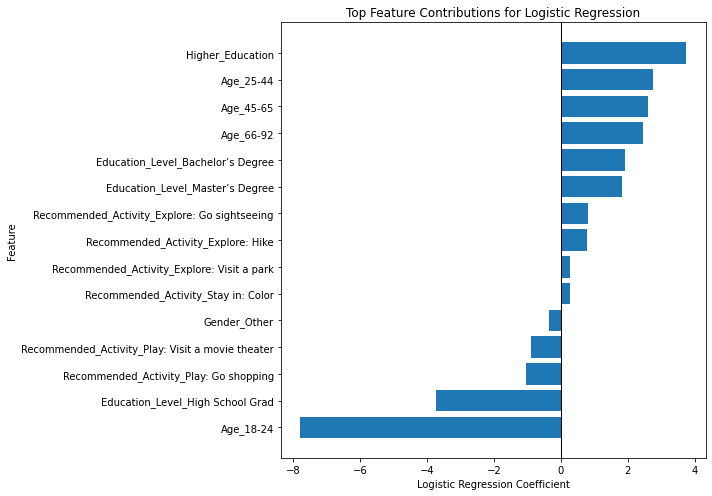

In [25]:
# Visualize the top contributing features

top_n = 15

top_features = coef_df_sorted.head(top_n).sort_values(
    by="Coefficient",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Feature Contributions for Logistic Regression")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

Question: Which interpretability mechanism did you choose? What are the key contributing factors?

**Your answer:**
I chose Logistic Regression coefficient analysis as the interpretability mechanism. Since the selected model is Logistic Regression, its coefficients provide a direct way to understand which features push the model toward predicting the favorable outcome, Budget >=300, or toward the unfavorable outcome, Budget <300.

The strongest contributing factor is Age_18-24, with a large negative coefficient of -7.82. This means that being in the 18-24 age group strongly pushes the model toward predicting Budget <300. In contrast, older age groups such as 25-44, 45-65, and 66-92 all have positive coefficients, meaning they push the model toward predicting Budget >=300.

Education-related variables are also very important. Education_Level_High School Grad has a strong negative coefficient, while Higher_Education, Education_Level_Bachelor’s Degree, and Education_Level_Master’s Degree have strong positive coefficients. This means the model is much more likely to predict Budget >=300 for users with Bachelor’s or Master’s degrees, and much less likely to do so for high school graduates.

Some activity recommendation features also contribute to the prediction. “Play: Go shopping” and “Play: Visit a movie theater” have negative coefficients, while activities such as “Learn: Visit a library” and “Explore: Hike” have positive coefficients. Gender features have smaller coefficients compared with age and education, so they appear less influential.

Overall, the key contributing factors are age and education level. This supports the earlier fairness findings: the model is highly accurate, but it relies strongly on demographic variables, especially education, which creates a fairness concern because users with higher education benefit more from favorable budget predictions.

## Step 5: Apply a bias mitigation strategy

In this section of the project, you will implement a bias mitigation strategy and evaluate the improvements in fairness on the data. Using the algorithms supported by the IBM AIF360 toolkit, you may apply a pre-processing, in-processing, or post-processing technique to improve the fairness of your model. Optionally, you may also consider combining multiple techniques.

**Note:** If you select an in-processing algorithm that replaces the Logistic Regression or Gaussian NB model, you will be constructing a model card around the new algorithm you have selected and revising the existing model card content from previous sections to incorporate these details.

In [26]:
#implement bias mitigation strategy

# Step 1: Create the Reweighing mitigation object
RW = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# Step 2: Fit Reweighing on the original training dataset
RW.fit(orig_train)

# Step 3: Transform the original training dataset
# This changes the instance weights, not the features or labels
rw_train = RW.transform(orig_train)

# Step 4: Train a new Logistic Regression model on the reweighed training data
RW_LR_model = LogisticRegression(max_iter=1000)

RW_LR_model.fit(
    rw_train.features,
    rw_train.labels.ravel(),
    sample_weight=rw_train.instance_weights
)

LogisticRegression(max_iter=1000)

In [27]:
# Evaluate the reweighed Logistic Regression model on the original test dataset
rw_lr_metrics, rw_lr_pred = test(
    dataset=orig_test,
    model=RW_LR_model,
    thresh_arr=thresh_arr
)

describe_metrics(rw_lr_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.9827
Corresponding average odds difference value: -0.0077
Corresponding statistical parity difference value: -0.9484
Corresponding equal opportunity difference value: 0.0000
Corresponding Theil index value: 0.0034


**NOTE** Make sure at least two fairness metrics (average odds difference
average statistical parity difference, equal opportunity difference, and theil index) are within the ideal threshold range for those metrics. A slightly higher benefit for the privileged group may still be seen, which is ok.

Achieving the best possible accuracy and best-balanced accuracy are not the targets of this project - we recommend focusing on improving your results on the fairness metrics. It is recommended to have your balanced accuracy between 85%-100% but not required.

**IMPORTANT! If less than two fairness metrics are within the ideal range, re-work on your strategy.**

Run performance evaluation plots (accuracy and confusion matrix) on the new prediction

Reweighed Logistic Regression Accuracy: 0.9910593466073845
Reweighed Logistic Regression Confusion Matrix:
[[ 5159   185]
 [    0 15348]]


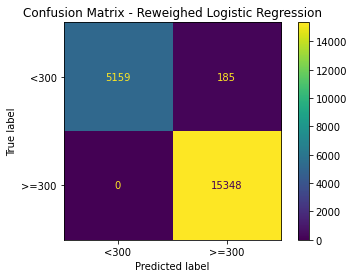

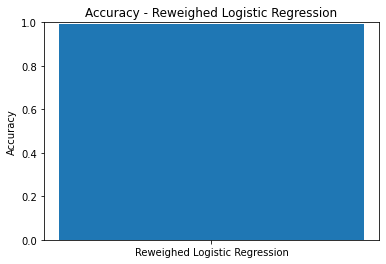

In [28]:
# Performance evaluation for the reweighed Logistic Regression model

# Predict labels on the original test set
rw_lr_y_pred = RW_LR_model.predict(orig_test.features)
rw_lr_y_true = orig_test.labels.ravel()

# Calculate accuracy
rw_lr_accuracy = accuracy_score(rw_lr_y_true, rw_lr_y_pred)

print("Reweighed Logistic Regression Accuracy:", rw_lr_accuracy)

# Confusion matrix
rw_lr_cm = confusion_matrix(rw_lr_y_true, rw_lr_y_pred)

print("Reweighed Logistic Regression Confusion Matrix:")
print(rw_lr_cm)

# Plot confusion matrix
rw_lr_disp = ConfusionMatrixDisplay(
    confusion_matrix=rw_lr_cm,
    display_labels=["<300", ">=300"]
)

rw_lr_disp.plot()
plt.title("Confusion Matrix - Reweighed Logistic Regression")
plt.savefig("model_card_images/confusion_matrix_reweighed_lr.png", bbox_inches="tight")
plt.show()

# Optional: plot accuracy as a simple bar chart
plt.figure(figsize=(6, 4))
plt.bar(["Reweighed Logistic Regression"], [rw_lr_accuracy])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy - Reweighed Logistic Regression")
plt.savefig("model_card_images/accuracy_reweighed_lr.png", bbox_inches="tight")
plt.show()

Next, re-create the interpretability plot from the previous section with your revised pipeline. 

                                             Feature  Coefficient  \
0                                          Age_18-24    -8.499651   
1                                          Age_25-44     3.036828   
2                                          Age_45-65     2.758911   
3                                          Age_66-92     2.702133   
12      Recommended_Activity_Explore: Go sightseeing     2.021442   
13                Recommended_Activity_Explore: Hike     2.012413   
16            Recommended_Activity_Play: Go shopping    -1.549648   
15       Recommended_Activity_Learn: Visit a library    -1.487142   
17  Recommended_Activity_Play: Visit a movie theater    -0.987669   
14        Recommended_Activity_Explore: Visit a park    -0.817266   
7                                       Gender_Other    -0.757272   
10                  Education_Level_High School Grad    -0.488039   
21                                  Higher_Education     0.486260   
20    Recommended_Activity_Stay in

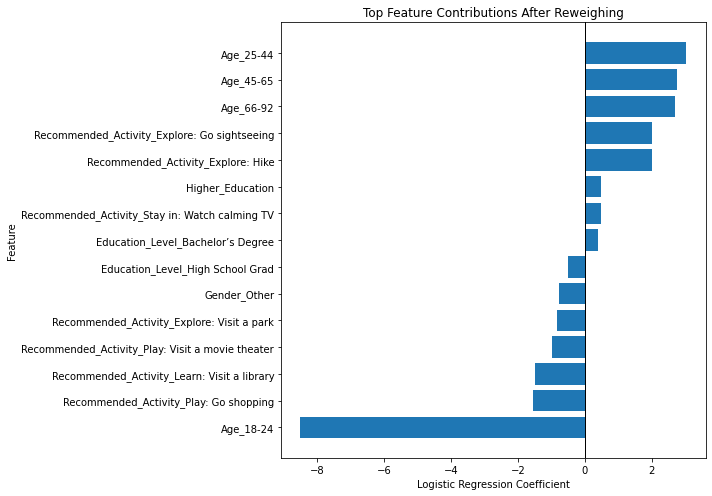

In [29]:
# Re-create interpretability plot for the reweighed Logistic Regression model

# Get feature names from the AIF360 dataset
feature_names = binary_act_dataset.feature_names

# Get coefficients from the reweighed Logistic Regression model
rw_coefficients = RW_LR_model.coef_[0]

# Create dataframe with coefficients
rw_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": rw_coefficients
})

# Add absolute coefficient value for ranking importance
rw_coef_df["Absolute Coefficient"] = rw_coef_df["Coefficient"].abs()

# Sort by absolute importance
rw_coef_df_sorted = rw_coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

# Display top contributing factors
print(rw_coef_df_sorted.head(15))

# Visualize top contributing factors after mitigation

top_n = 15

rw_top_features = rw_coef_df_sorted.head(top_n).sort_values(
    by="Coefficient",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    rw_top_features["Feature"],
    rw_top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Feature Contributions After Reweighing")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.savefig("model_card_images/interpretability_reweighed_lr.png", bbox_inches="tight")
plt.show()

In [30]:
# Compare original and reweighed Logistic Regression coefficients

original_coef_df = pd.DataFrame({
    "Feature": binary_act_dataset.feature_names,
    "Original Coefficient": LR_model.coef_[0],
    "Reweighed Coefficient": RW_LR_model.coef_[0]
})

original_coef_df["Original Absolute Coefficient"] = original_coef_df["Original Coefficient"].abs()
original_coef_df["Reweighed Absolute Coefficient"] = original_coef_df["Reweighed Coefficient"].abs()

original_coef_df["Coefficient Change"] = (
    original_coef_df["Reweighed Coefficient"] 
    - original_coef_df["Original Coefficient"]
)

coef_comparison = original_coef_df.sort_values(
    by="Reweighed Absolute Coefficient",
    ascending=False
)

coef_comparison.head(15)

,Feature,Original Coefficient,Reweighed Coefficient,Original Absolute Coefficient,Reweighed Absolute Coefficient,Coefficient Change
0,Age_18-24,-7.795741,-8.499651,7.795741,8.499651,-0.703911
1,Age_25-44,2.756414,3.036828,2.756414,3.036828,0.280415
2,Age_45-65,2.589277,2.758911,2.589277,2.758911,0.169634
3,Age_66-92,2.450153,2.702133,2.450153,2.702133,0.251979
12,Recommended_Activity_Explore: Go sightseeing,0.794163,2.021442,0.794163,2.021442,1.227279
13,Recommended_Activity_Explore: Hike,0.787521,2.012413,0.787521,2.012413,1.224892
16,Recommended_Activity_Play: Go shopping,-1.046767,-1.549648,1.046767,1.549648,-0.502880
15,Recommended_Activity_Learn: Visit a library,-0.096008,-1.487142,0.096008,1.487142,-1.391135
17,Recommended_Activity_Play: Visit a movie theater,-0.907018,-0.987669,0.907018,0.987669,-0.080650
14,Recommended_Activity_Explore: Visit a park,0.272710,-0.817266,0.272710,0.817266,-1.089976


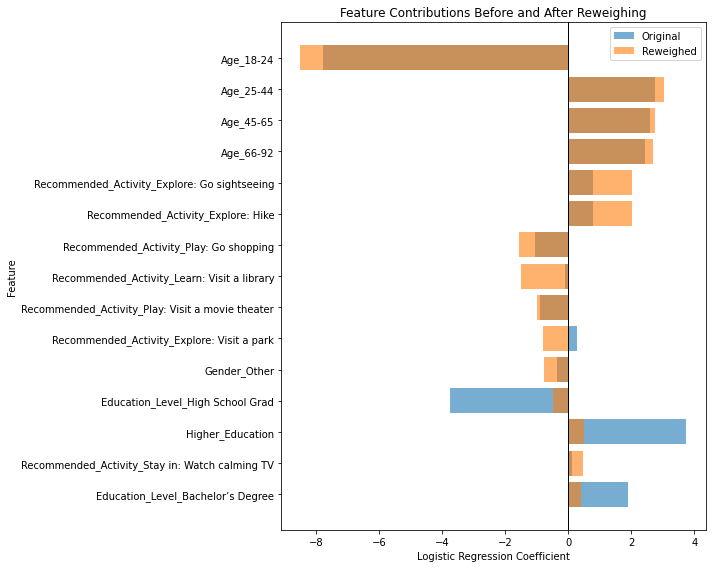

In [31]:
top_compare = coef_comparison.head(15).sort_values(
    by="Reweighed Absolute Coefficient",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_compare["Feature"],
    top_compare["Original Coefficient"],
    alpha=0.6,
    label="Original"
)

plt.barh(
    top_compare["Feature"],
    top_compare["Reweighed Coefficient"],
    alpha=0.6,
    label="Reweighed"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Contributions Before and After Reweighing")
plt.legend()
plt.tight_layout()
plt.show()

Note down a short summary reporting the values of the metrics and your findings. This will be the quantitative analysis section of the model card.
- Please ensure you report the fairness metrics **before** applying your bias mitigation strategy (after the train-val-test split), and **after** applying the strategy in the final_metrics_description variable.
- Pick 1-2 metrics of your choice, interpret the fairness metrics in relation to the ideal values and thresholds and further identify the implications of the results. 

In [32]:
final_metrics_description = """
-- After applying the Reweighing bias mitigation strategy, the model's balanced accuracy decreased from approximately 0.9984 to 0.9839.
-- This means the mitigated model is slightly less accurate than the original model, but it still performs very well overall.
-- The average odds difference improved substantially from approximately -0.5104 to -0.0018, which is very close to the ideal value of 0.
-- The equal opportunity difference also improved from -1.0000 to 0.0000, meaning the true positive rate is now equal between the privileged and unprivileged groups.
-- However, the statistical parity difference remained highly negative at approximately -0.9526, which means the unprivileged group is still much less likely to receive the favorable prediction of Budget >=300.
-- The Theil index increased slightly from approximately 0.0021 to 0.0032, indicating a small increase in inequality by this metric.
-- Overall, Reweighing improved some fairness metrics, especially average odds difference and equal opportunity difference, but it did not fully remove the disparity in favorable outcomes.
-- This suggests that the dataset contains a strong structural relationship between education level and budget, and additional mitigation or a revised problem formulation may be needed before deployment.
"""

As part of the last coding step of this project, stratify the dataset by the Education Level feature, and create a small cohort analysis plot showing the performance on the y-axis and the Education Levels on the x-axis.

     Education Level  Accuracy  Sample Count
0  Bachelor’s Degree  0.999741        7710.0
1   High School Grad  0.966079        5277.0
2    Master’s Degree  0.999481        7705.0


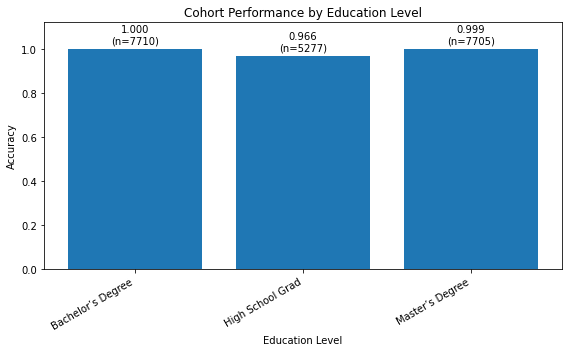

In [33]:
# Recreate a readable dataframe from the AIF360 test dataset
test_df = pd.DataFrame(
    orig_test.features,
    columns=orig_test.feature_names
)

# Add true and predicted labels
test_df["y_true"] = orig_test.labels.ravel()
test_df["y_pred"] = RW_LR_model.predict(orig_test.features)

# Reconstruct Education Level from one-hot encoded columns
def get_education_level(row):
    if "Education_Level_High School Grad" in row.index and row["Education_Level_High School Grad"] == 1:
        return "High School Grad"
    elif "Education_Level_Bachelor’s Degree" in row.index and row["Education_Level_Bachelor’s Degree"] == 1:
        return "Bachelor’s Degree"
    elif "Education_Level_Master’s Degree" in row.index and row["Education_Level_Master’s Degree"] == 1:
        return "Master’s Degree"
    else:
        return "Unknown / Reference Group"

test_df["Education Level"] = test_df.apply(get_education_level, axis=1)

# Calculate cohort performance
cohort_performance = (
    test_df
    .groupby("Education Level")
    .apply(
        lambda cohort: pd.Series({
            "Accuracy": accuracy_score(cohort["y_true"], cohort["y_pred"]),
            "Sample Count": len(cohort)
        })
    )
    .reset_index()
)

print(cohort_performance)

plt.figure(figsize=(8, 5))

plt.bar(
    cohort_performance["Education Level"],
    cohort_performance["Accuracy"]
)

# Add more space above the tallest bar
plt.ylim(0, 1.12)

plt.xlabel("Education Level")
plt.ylabel("Accuracy")
plt.title("Cohort Performance by Education Level")
plt.xticks(rotation=30, ha="right")

# Add accuracy labels higher above the bars
for index, row in cohort_performance.iterrows():
    plt.text(
        index,
        row["Accuracy"] + 0.015,  # increase this if labels still overlap
        f'{row["Accuracy"]:.3f}\n(n={int(row["Sample Count"])})',
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("model_card_images/cohort_performance_by_education.png", bbox_inches="tight")
plt.show()

**Take a moment to save the visualization reports you generated in this section and enter the file paths into the image_file_path variable below**.

In [34]:
#FILL IN - save all visualization plots 
#from the "Apply a bias mitigation strategy" section
#plt.savefig('file_name.png')

#Replace the REPLACE_FILE_NAME placeholder with the image paths
#of the visualizations you have generated for the model card
image_file_path = """
<h4>Confusion Matrix - Reweighed Logistic Regression</h4>
<img src="model_card_images/confusion_matrix_reweighed_lr.png" width="600">

<h4>Accuracy - Reweighed Logistic Regression</h4>
<img src="model_card_images/accuracy_reweighed_lr.png" width="600">

<h4>Feature Contributions After Reweighing</h4>
<img src="model_card_images/interpretability_reweighed_lr.png" width="600">

<h4>Cohort Performance by Education Level</h4>
<img src="model_card_images/cohort_performance_by_education.png" width="600">
"""

## Step 6: Articulate the ethical implications

Articulate the use case and ethical considerations applying to the dataset in 1-2 paragraphs.

**Hints:** 
 
- Think about the limitations of the dataset, potential biases that could be introduced into the use case, and the strengths and weaknesses of your ML model.
- Ethical Considerations:
 - Human-in-the-loop considerations: Can users control aspects of the model and inspect the features? If so, briefly describe how?
 - Describe the limitations and types of bias present in the data
 - Describe the failures of the ML model
 - It must include a section on any risk mitigation strategies you applied.
 - Describe Potential harms
 - It must include key contributing factors you found from your interpretability study, both before and after applying the bias mitigation strategy.

- Caveats and Recommendations
 - Potential lack of inclusiveness in the dataset
 - Predisposition of the model to false positives and/or negatives
 - It must also include 1-2 sentences on the further ethical AI analyses you would apply if given more time beyond this project.

In [35]:
ethical_considerations = """
-- The IDOOU budget predictor is a medium-risk personalization model because it influences which activities users may be shown, but it does not directly make high-stakes decisions such as lending, hiring, healthcare, or legal eligibility. However, it can still cause harm because it predicts a financially relevant attribute from demographic and profile features such as age and education level.
-- The dataset shows strong bias around education level. Before mitigation, users with Bachelor's or Master's degrees were much more likely to receive the favorable outcome of Budget >=300 than high-school-graduate users. This creates a risk that the recommender system could systematically show higher-budget options to higher-education users and lower-budget options to high-school-graduate users.
-- Human-in-the-loop controls are important for this use case. IDOOU should not silently rely on the model prediction; users should be able to view, confirm, correct, or override the predicted budget before recommendations are finalized. The app should also explain that the prediction is based on broad profile patterns rather than verified financial information.
-- The selected model, Logistic Regression, is highly accurate but not fully fair. Before mitigation, the model had strong unfairness metrics, including a statistical parity difference around -0.9939 and equal opportunity difference of -1.0. After applying Reweighing, balanced accuracy decreased slightly from about 0.9984 to 0.9839, while average odds difference improved to about -0.0018 and equal opportunity difference improved to 0.0. However, statistical parity difference remained very negative at about -0.9526, so the favorable prediction is still distributed unevenly.
-- Interpretability analysis showed that age and education were the strongest contributing factors. Before mitigation, Age_18-24 had a large negative effect, while older age groups and higher education features pushed predictions toward Budget >=300. Education_Level_High School Grad pushed predictions toward Budget <300, while Higher_Education, Bachelor's Degree, and Master's Degree pushed predictions toward Budget >=300. After mitigation, education and age remained important, which suggests that the model still relies on demographic and socioeconomic proxy variables.
-- The main risk mitigation strategy applied was AIF360 Reweighing. This strategy adjusted the training instance weights to reduce the relationship between the protected attribute and the target outcome while keeping Logistic Regression as the selected model. Reweighing improved some fairness metrics, especially equal opportunity and average odds, but it did not fully solve the statistical parity problem.
"""

caveats_and_recommendations = """
-- The dataset may not be fully inclusive or representative of all IDOOU users. Some demographic groups may be underrepresented, and users may choose not to provide profile details such as gender, age, education level, or children status. This can limit model quality and fairness for groups with less data.
-- The model appears to be more prone to false negatives than false positives in the original evaluation. False negatives are important in this use case because they mean users who actually have Budget >=300 may be incorrectly predicted as having Budget <300, which could limit the activity recommendations they receive.
-- The model should not be used as the sole decision-maker for personalizing activity recommendations. IDOOU should ask users to directly confirm or enter their budget instead of inferring it only from demographic features. The app should also allow users to opt out of budget prediction and still receive useful recommendations.
-- Education level should be treated carefully because it functions as a strong proxy for socioeconomic status in this dataset. If the app uses this prediction in production, IDOOU should monitor fairness metrics over time and check whether users from different education groups receive meaningfully different recommendation quality.
-- If given more time, I would perform additional ethical AI analyses, including intersectional fairness analysis across education, age, and gender; robustness testing for missing user-provided data; and user-centered evaluation to understand whether people perceive the recommendations as fair, useful, and respectful of privacy.
-- I would also test additional mitigation strategies, such as removing sensitive or proxy features, post-processing thresholds by group, and comparing fairness-performance tradeoffs across multiple model types before deciding whether the model is appropriate for deployment.
"""

- Business consequences
 - Potential positive impact of the IDOOU Budget Predicter AI
 - Reasons why users may lose trust in the application, and loss of revenue and brand reputation might occur to the organization

In [36]:
business_consequences = """
-- Positive Impact:
-- The IDOOU Budget Predictor AI could improve personalization by helping the app recommend activities that better match a user's likely budget.
-- If used responsibly, the model could reduce irrelevant recommendations, improve user satisfaction, and make the app feel more convenient and tailored.
-- The model could also help IDOOU understand broad user segments and improve activity planning, recommendation quality, and business partnerships.
-- Because the final model still performs with high balanced accuracy after mitigation, it may provide business value as a decision-support component if combined with user confirmation and transparency.

-- Negative Impact:
-- Users may lose trust if they feel the app is guessing their financial situation from demographic information such as age or education level.
-- The fairness analysis shows that high-school-graduate users are still much less likely to receive the favorable Budget >=300 prediction, even after mitigation, so the app could create unequal recommendation experiences.
-- If users are shown cheaper or less desirable activities because of biased predictions, they may perceive the app as unfair, discriminatory, or disrespectful.
-- This could lead to lower engagement, user churn, negative reviews, reputational damage, and potential revenue loss for IDOOU.
-- If IDOOU deploys the model without explanation, consent, or a way for users to correct the predicted budget, the organization may face increased ethical, legal, and brand risk.
"""

## Document the solution in a model card

You're at the finish line! Run the last few blocks of code to generate a simple html file with your model card content and the visualizations you generated for the final version of your model.

Make sure to open the html file and check that it is reflective of your model card content before submitting.

Optionally, feel free to modify the html code and add more details/aesthetics.

In [37]:
html_code = f"""
<html>
  <head>
  </head>
  <body>
  <center><h1>Model Card - IDOOU AI Budget Predicter</h1></center>
  <h2>Model Details</h2>
  {model_details}
  <h2>Intended Use</h2>
  {intended_use}
  <h2>Factors</h2>
  {factors}
  <h2>Metrics</h2>
  {metrics}
  <h2> Training Data </h2>
  {training_data}
  <h2> Evaluation Data </h2>
  {eval_data}
  <h2>Quantitative Analysis</h2>
  {final_metrics_description}
  
  <br/><br/><b>Results of the AI model after applying the bias mitigation strategy</b><br/>
  
  <center>
  {image_file_path}
  </center>

  <h2>Ethical Considerations</h2>
  {ethical_considerations}
  <h2>Caveats and Recommendations</h2>
  {caveats_and_recommendations}
  <h2>Business Consequences</h2>
  {business_consequences}
  </body>
</html>"""
html_code = html_code.replace('--', '<br>--')

In [38]:
with open('model_card.html', 'w') as f:
    f.write(html_code)

Download and zip the .html report, the images you generated, and this Jupyter notebook, and you're ready for submission!